<a href="https://www.kaggle.com/code/bishaladhikari07/bank-classification?scriptVersionId=268208906" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Binary Classification Bank

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e8/sample_submission.csv
/kaggle/input/playground-series-s5e8/train.csv
/kaggle/input/playground-series-s5e8/test.csv


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
print('Hello world')

Hello world


In [4]:
df_train=pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv')
df_train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [5]:
df_train.shape

(750000, 18)

In [6]:
df_test=pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv')
df_test.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
1,750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
2,750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
3,750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
4,750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown


In [7]:
df_test.shape

(250000, 17)

In [8]:
df_train.shape

(750000, 18)

In [9]:
df=pd.concat([df_train,df_test],axis=0,ignore_index=True)

In [10]:
df.shape

(1000000, 18)

In [11]:
df.isna().sum()

id                0
age               0
job               0
marital           0
education         0
default           0
balance           0
housing           0
loan              0
contact           0
day               0
month             0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
y            250000
dtype: int64

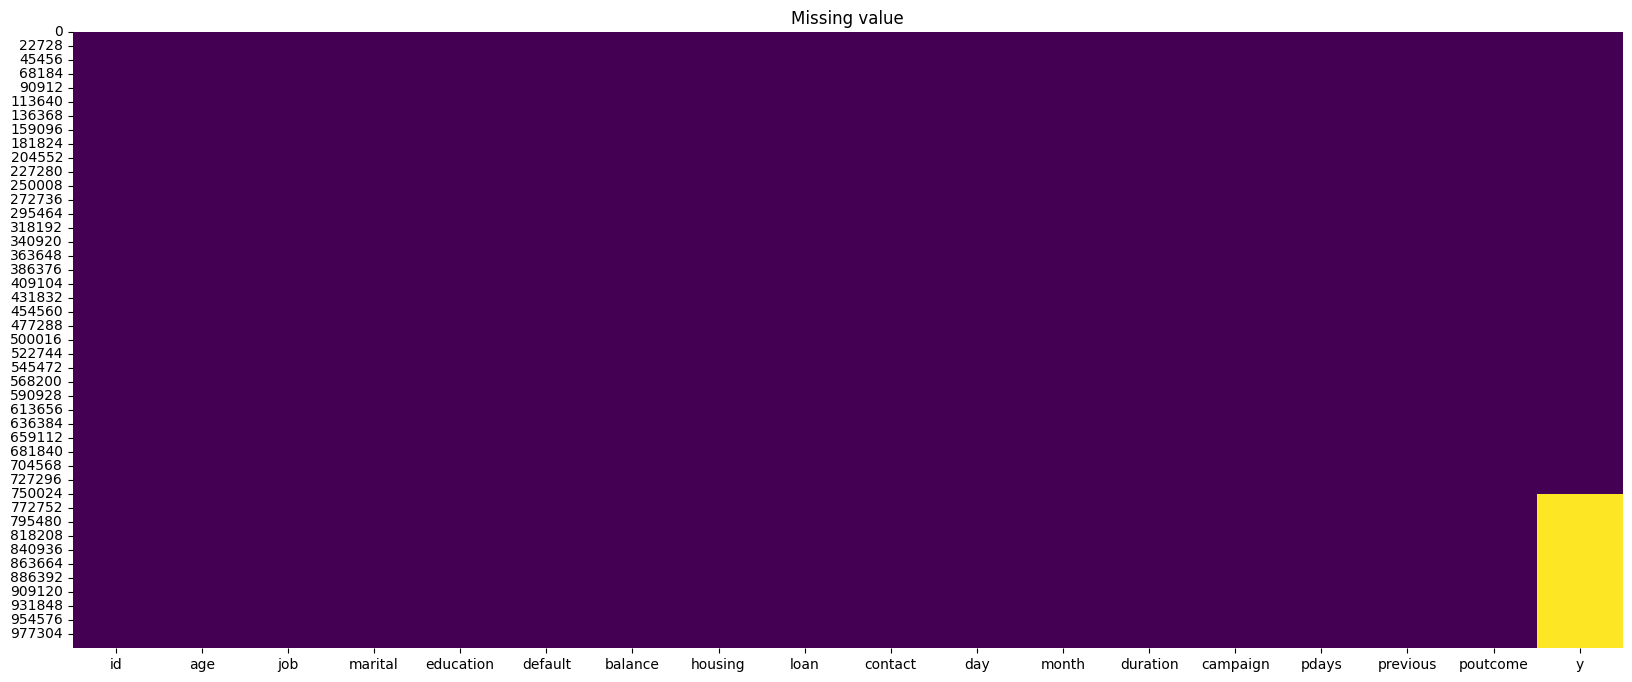

In [12]:
plt.figure(figsize=(20,8))
sns.heatmap(df.isna(),cbar=False,cmap='viridis')
plt.title("Missing value")
plt.show()

In [13]:
# sns.pairplot(df)

In [14]:
df['pdays'].tail()

999995     -1
999996    189
999997     92
999998     -1
999999     -1
Name: pdays, dtype: int64

In [15]:
df['pdays'].value_counts()

pdays
-1      896546
 182      3331
 92       3047
 183      2755
 91       2290
         ...  
 614         1
 794         1
 735         1
 759         1
 624         1
Name: count, Length: 614, dtype: int64

In [16]:
# df['balance_log']=np.log1p(df['balance'])
df['previous_log']=np.log1p(df['previous'])
df['campaign_log']=np.log1p(df['campaign'])
df['duration_log']=np.log1p(df['duration'])
# df['pdays_log']=np.log1p(df['pdays'])



In [17]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y', 'previous_log', 'campaign_log',
       'duration_log'],
      dtype='object')

In [18]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y', 'previous_log', 'campaign_log',
       'duration_log'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 21 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   id            1000000 non-null  int64  
 1   age           1000000 non-null  int64  
 2   job           1000000 non-null  object 
 3   marital       1000000 non-null  object 
 4   education     1000000 non-null  object 
 5   default       1000000 non-null  object 
 6   balance       1000000 non-null  int64  
 7   housing       1000000 non-null  object 
 8   loan          1000000 non-null  object 
 9   contact       1000000 non-null  object 
 10  day           1000000 non-null  int64  
 11  month         1000000 non-null  object 
 12  duration      1000000 non-null  int64  
 13  campaign      1000000 non-null  int64  
 14  pdays         1000000 non-null  int64  
 15  previous      1000000 non-null  int64  
 16  poutcome      1000000 non-null  object 
 17  y             750000 non-nul

In [20]:
month_to_num = {'jan':1, 'feb':2, 'mar':3, 'apr':4, 'may':5, 'jun':6,
                'jul':7, 'aug':8, 'sep':9, 'oct':10, 'nov':11, 'dec':12}
df['month_num'] = df['month'].map(month_to_num)
df['day_of_year'] = (df['month_num'] - 1)*30 + df['day']  # approx


In [21]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y', 'previous_log', 'campaign_log',
       'duration_log', 'month_num', 'day_of_year'],
      dtype='object')

In [22]:
df['campaign'].value_counts()

campaign
1     406170
2     279872
3     118070
4      81197
5      34127
6      26318
7      13801
8      10312
9       5366
10      4697
11      3405
12      2748
13      2355
14      1652
15      1476
16      1330
17      1209
18       864
20       717
19       712
21       546
22       363
25       352
23       321
24       278
29       241
28       234
31       202
26       180
27       146
30       138
32       122
33        95
35        71
34        63
38        42
37        39
36        39
41        22
43        19
50        15
40        13
39        12
44        12
51         9
46         8
45         6
42         5
48         4
55         2
58         2
63         1
Name: count, dtype: int64

In [23]:
df=df.drop(['previous','month','campaign','duration'],axis=1,errors='ignore')

In [24]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,pdays,poutcome,y,previous_log,campaign_log,duration_log,month_num,day_of_year
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,-1,unknown,0.0,0.0,1.386294,4.770685,8,235
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,-1,unknown,0.0,0.0,0.693147,5.225747,6,168
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,-1,unknown,0.0,0.0,1.098612,4.718499,5,134
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,-1,unknown,0.0,0.0,1.098612,2.397895,5,148
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,-1,unknown,1.0,0.0,0.693147,6.805723,2,33


In [25]:
# df['pdays'].value_counts()

In [26]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,pdays,poutcome,y,previous_log,campaign_log,duration_log,month_num,day_of_year
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,-1,unknown,0.0,0.0,1.386294,4.770685,8,235
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,-1,unknown,0.0,0.0,0.693147,5.225747,6,168
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,-1,unknown,0.0,0.0,1.098612,4.718499,5,134
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,-1,unknown,0.0,0.0,1.098612,2.397895,5,148
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,-1,unknown,1.0,0.0,0.693147,6.805723,2,33


In [27]:
df.shape

(1000000, 19)

In [28]:
df_dataset_train=df[:750000]
df_dataset_test=df[750000:]

In [29]:
df_dataset_train_x=df_dataset_train.drop(['y'],axis=1)


In [30]:
df['default']=df['default'].map({'yes':1,'no':0})
df['housing']=df['housing'].map({'yes':1,'no':0})
df['loan']=df['loan'].map({'yes':1,'no':0})



In [31]:
skewness = df.skew(numeric_only=True)
skewness[abs(skewness) > 1]  # hig

default          7.471295
balance         12.163917
loan             2.074769
pdays            3.625560
y                2.329296
previous_log     3.623411
campaign_log     1.323078
dtype: float64

In [32]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,pdays,poutcome,y,previous_log,campaign_log,duration_log,month_num,day_of_year
0,0,42,technician,married,secondary,0,7,0,0,cellular,25,-1,unknown,0.0,0.0,1.386294,4.770685,8,235
1,1,38,blue-collar,married,secondary,0,514,0,0,unknown,18,-1,unknown,0.0,0.0,0.693147,5.225747,6,168
2,2,36,blue-collar,married,secondary,0,602,1,0,unknown,14,-1,unknown,0.0,0.0,1.098612,4.718499,5,134
3,3,27,student,single,secondary,0,34,1,0,unknown,28,-1,unknown,0.0,0.0,1.098612,2.397895,5,148
4,4,26,technician,married,secondary,0,889,1,0,cellular,3,-1,unknown,1.0,0.0,0.693147,6.805723,2,33


In [33]:
# from sklearn.preprocessing import OneHotEncoder,StandardScaler
# from sklearn.compose import ColumnTransformer

# numerical_feature=['age','day','day_of_year']
# categorical_feature=['job','marital','education','contact','poutcome']


# nontreebased_transformer=ColumnTransformer([
#     ('num',StandardScaler(),numerical_feature),
#     ('cat',OneHotEncoder(),categorical_feature)
# ])


# nontreetransformed_train_x=nontreebased_transformer.fit_transform(df_dataset_train_x)
# nontreetransformed_test_x=nontreebased_transformer.transform(df_dataset_test)




# from sklearn.preprocessing import OneHotEncoder,StandardScaler
# from sklearn.compose import ColumnTransformer

# categorical_feature=['job','marital','education','contact','poutcome']


# treebased_transformer=ColumnTransformer([
#     ('cat',OneHotEncoder(),categorical_feature)
# ])


# treetransformed_train_x=nontreebased_transformer.fit_transform(df_dataset_train_x)
# treetransformed_test_x=nontreebased_transformer.transform(df_dataset_test)




# good but the better way of doing is below



In [34]:
df.shape

(1000000, 19)

In [35]:
df_final=df.drop(['id'],axis=1)


In [36]:


df_train_CD=df_final[:750000]
df_train_CD.head()



df_train_CD_x=df_train_CD.drop(['y'],axis=1)
df_train_CD_y=df_train_CD['y']
df_train_CD_y

0         0.0
1         0.0
2         0.0
3         0.0
4         1.0
         ... 
749995    1.0
749996    0.0
749997    0.0
749998    0.0
749999    0.0
Name: y, Length: 750000, dtype: float64

In [37]:
df_test_CD=df_final[750000:]
df_test_CD.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,age,job,marital,education,default,balance,housing,loan,contact,day,pdays,poutcome,y,previous_log,campaign_log,duration_log,month_num,day_of_year
750000,32,blue-collar,married,secondary,0,1397,1,0,unknown,21,-1,unknown,NaN,0.0,0.693147,5.416100,5,141
750001,44,management,married,tertiary,0,23,1,0,cellular,3,-1,unknown,NaN,0.0,1.098612,6.375025,4,93
750002,36,self-employed,married,primary,0,46,1,1,cellular,13,-1,unknown,NaN,0.0,1.098612,4.718499,5,133
750003,58,blue-collar,married,secondary,0,-1380,1,1,unknown,29,-1,unknown,NaN,0.0,0.693147,4.836282,5,149
750004,28,technician,single,secondary,0,1950,1,0,cellular,22,-1,unknown,NaN,0.0,0.693147,5.204007,7,202


In [38]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

numeric_features=['age','day','day_of_year']
categorical_features=['job','marital','education','contact','poutcome']

# Tree-based pipeline
tree_preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
], remainder='passthrough')



tree_models={
    'RFModel' : Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
]),
    'GBModel' : Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', GradientBoostingClassifier())
]),
        "XGBoostModel": Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
    ])
    
}
    


# Non-tree pipeline
non_tree_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
],remainder='passthrough')


non_tree_models={
    
    'LRModel':Pipeline([
        ('preprocessor',non_tree_preprocessor),
        ('model',LogisticRegression())
    ]),
    
    'KNNModel':Pipeline([
    ('preprocessor',non_tree_preprocessor),
    ('model',KNeighborsClassifier())
    ]),
    'SVMModel':Pipeline([
        ('preprocessor',non_tree_preprocessor),
        ('model',SVC())
    ])
    
    
    
}






In [39]:
from sklearn.model_selection import cross_val_score, train_test_split, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score



# Split into train/test for confusion matrix visualization (optional)
X_train, X_test, y_train, y_test = train_test_split(df_train_CD_x, df_train_CD_y, test_size=0.2, random_state=42)



# Combine both tree and non-tree models
# all_models = 
# {**tree_models, **non_tree_models}

In [40]:


# for name, model_pipeline in tree_models.items():
#     print(f"\n=== {name} ===")
    
#     # Fit the pipeline on training data
#     model_pipeline.fit(X_train, y_train)
    
#     # Predictions
#     y_pred = model_pipeline.predict(X_test)
    
#     # Confusion matrix
#     cm = confusion_matrix(y_test, y_pred)
#     print("Confusion Matrix:\n", cm)
    
#     # Classification report (accuracy, precision, recall, f1-score)
#     print("Classification Report:\n", classification_report(y_test, y_pred))
    
#     # Optional: cross-validation score for more robust metric
#     scores = cross_val_score(model_pipeline, df_train_CD_x, df_train_CD_y, cv=5, scoring='accuracy')
#     print("5-fold CV Accuracy:", scores.mean())


In [41]:


# for name, model_pipeline in non_tree_models.items():
#     print(f"\n=== {name} ===")
    
#     # Fit the pipeline on training data
#     model_pipeline.fit(X_train, y_train)
    
#     # Predictions
#     y_pred = model_pipeline.predict(X_test)
    
#     # Confusion matrix
#     cm = confusion_matrix(y_test, y_pred)
#     print("Confusion Matrix:\n", cm)
    
#     # Classification report (accuracy, precision, recall, f1-score)
#     print("Classification Report:\n", classification_report(y_test, y_pred))
    
#     # Optional: cross-validation score for more robust metric
#     scores = cross_val_score(model_pipeline, df_train_CD_x, df_train_CD_y, cv=5, scoring='accuracy')
#     print("5-fold CV Accuracy:", scores.mean())


In [42]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'model__n_estimators': [100, 200, 300],
#     'model__max_depth': [3, 5, 7],
#     'model__learning_rate': [0.01, 0.1, 0.3],
#     'model__subsample': [0.8, 1.0],
#     'model__colsample_bytree': [0.8, 1.0]
# }

# grid_search = GridSearchCV(tree_models['XGBoostModel'], param_grid, 
#                            cv=3, scoring='accuracy', n_jobs=-1)

# grid_search.fit(X_train, y_train)

# print("Best Parameters:", grid_search.best_params_)
# print("Best CV Accuracy:", grid_search.best_score_)


In [43]:
df.shape

(1000000, 19)

In [44]:

from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

best_params = {
    'colsample_bytree': 1.0,
    'learning_rate': 0.1,
    'max_depth': 7,
    'n_estimators': 300,
    'subsample': 0.8
}

final_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', XGBClassifier(**best_params, random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)


In [45]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Error Rate:", 1 - accuracy_score(y_test, y_pred))



Test Accuracy: 0.9357

Classification Report:
               precision    recall  f1-score   support

         0.0       0.96      0.97      0.96    131795
         1.0       0.77      0.68      0.72     18205

    accuracy                           0.94    150000
   macro avg       0.86      0.82      0.84    150000
weighted avg       0.93      0.94      0.93    150000


Confusion Matrix:
 [[128016   3779]
 [  5866  12339]]
Error Rate: 0.06430000000000002


In [46]:
df_test_CD_x=df_test_CD.drop(['y'],axis=1)

In [47]:
df_test_CD_x.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,pdays,poutcome,previous_log,campaign_log,duration_log,month_num,day_of_year
750000,32,blue-collar,married,secondary,0,1397,1,0,unknown,21,-1,unknown,0.0,0.693147,5.416100,5,141
750001,44,management,married,tertiary,0,23,1,0,cellular,3,-1,unknown,0.0,1.098612,6.375025,4,93
750002,36,self-employed,married,primary,0,46,1,1,cellular,13,-1,unknown,0.0,1.098612,4.718499,5,133
750003,58,blue-collar,married,secondary,0,-1380,1,1,unknown,29,-1,unknown,0.0,0.693147,4.836282,5,149
750004,28,technician,single,secondary,0,1950,1,0,cellular,22,-1,unknown,0.0,0.693147,5.204007,7,202


In [48]:
test_preds=final_model.predict(df_test_CD_x)
test_preds

array([0, 0, 0, ..., 1, 0, 0])

In [49]:
submission = pd.DataFrame({
    "id": df_test["id"],  # must come from original test.csv
    "y": test_preds   # 1D array is fine
})

# Save for Kaggle
submission.to_csv("submission.csv", index=False)

print("✅ submission.csv ready with shape:", submission.shape)
submission.head()

✅ submission.csv ready with shape: (250000, 2)


,id,y
0,750000,0
1,750001,0
2,750002,0
3,750003,0
4,750004,0
